In [1]:
import re
import pandas as pd
import numpy as np
import os

In [2]:
DATA_DIR = r'C:\Users\ASUS\Downloads\Heart-Disease-Prediction-Using-Machine-Learning\data\raw'

In [3]:
UCI_COLUMNS_75 = [
    'id', 'ccf', 'age', 'sex', 'painloc', 'painexer', 'relrest', 'pncaden',
    'cp', 'trestbps', 'htn', 'chol', 'smoke', 'cigs', 'years', 'fbs',
    'dm', 'famhist', 'restecg', 'ekgmo', 'ekgday', 'ekgyr', 'dig', 'prop',
    'nitr', 'pro', 'diuretic', 'proto', 'thaldur', 'thaltime', 'met',
    'thalach', 'thalrest', 'tpeakbps', 'tpeakbpd', 'dummy', 'trestbpd',
    'exang', 'xhypo', 'oldpeak', 'slope', 'rldv5', 'rldv5e', 'ca', 'restckm',
    'exerckm', 'restef', 'restwm', 'exeref', 'exerwm', 'thal', 'thalsev',
    'thalpul', 'earlobe', 'cmo', 'cday', 'cyr', 'num', 'lmt', 'ladprox',
    'laddist', 'diag', 'cxmain', 'ramus', 'om1', 'om2', 'rcaprox', 'rcadist',
    'lvx1', 'lvx2', 'lvx3', 'lvx4', 'lvf', 'cathef', 'junk'
]

In [4]:
def parse_uci_file(filepath, source_name):
    # Open the file (latin-1 handles special characters in the files)
    with open(filepath, 'r', encoding='latin-1') as f:
        content = f.read()

    # Extract all numbers and the word "name" from the raw text
    # Each patient's data ends with the word "name"
    tokens = re.findall(r'-?\d+\.?\d*|name', content)

    # Go through all tokens and collect 75 numbers before each "name"
    records = []
    i = 0
    while i < len(tokens):
        if tokens[i] == 'name':
            if i >= 75:
                records.append(tokens[i - 75 : i])  # one patient = 75 values
            i += 1
        else:
            i += 1

    # Turn the list of records into a DataFrame
    df = pd.DataFrame(records, columns=UCI_COLUMNS_75)
    df['source'] = source_name   # remember which file this came from
    return df

In [5]:
files = {
    'cleveland':     os.path.join(DATA_DIR, 'cleveland.data'),
    'hungarian':     os.path.join(DATA_DIR, 'hungarian.data'),
    'long-beach-va': os.path.join(DATA_DIR, 'long-beach-va.data'),
    'switzerland':   os.path.join(DATA_DIR, 'switzerland.data'),
    'new':           os.path.join(DATA_DIR, 'new.data'),
}

# Parse each file — this gives you 5 separate DataFrames
all_dfs = []
for name, path in files.items():
    df_temp = parse_uci_file(path, name)
    print(f"{name}: {len(df_temp)} patients")
    all_dfs.append(df_temp)

# pd.concat() stacks all 5 DataFrames on top of each other → 1 big DataFrame
combined = pd.concat(all_dfs, ignore_index=True)
#                              ↑
#     ignore_index=True resets row numbers from 0 to 1216
#     (instead of 0-292, then 0-293 again, etc.)

print(f"Total: {len(combined)} patients")

cleveland: 293 patients
hungarian: 294 patients
long-beach-va: 200 patients
switzerland: 123 patients
new: 307 patients
Total: 1217 patients


In [17]:
df = combined.copy()

In [27]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [28]:
df.head()

,id,ccf,age,sex,painloc,painexer,relrest,pncaden,cp,trestbps,htn,chol,smoke,cigs,years,fbs,dm,famhist,restecg,ekgmo,ekgday,ekgyr,dig,prop,nitr,pro,diuretic,proto,thaldur,thaltime,met,thalach,thalrest,tpeakbps,tpeakbpd,dummy,trestbpd,exang,xhypo,oldpeak,slope,rldv5,rldv5e,ca,restckm,exerckm,restef,restwm,exeref,exerwm,thal,thalsev,thalpul,earlobe,cmo,cday,cyr,num,lmt,ladprox,laddist,diag,cxmain,ramus,om1,om2,rcaprox,rcadist,lvx1,lvx2,lvx3,lvx4,lvf,cathef,junk,source
0,1,0,63,1,-9,-9,-9,-9,1,145,1,233,-9,50,20,1,-9,1,2,2,3,81,0,0,0,0,0,1,10.5,6,13,150,60,190,90,145,85,0,0,2.3,3,-9,172,0,-9,-9,-9,-9,-9,-9,6,-9,-9,-9,2,16,81,0,1,1,1,-9,1,-9,1,-9,1,1,1,1,1,1,1,-9,-9,cleveland
1,2,0,67,1,-9,-9,-9,-9,4,160,1,286,-9,40,40,0,-9,1,2,3,5,81,0,1,0,0,0,1,9.5,6,13,108,64,160,90,160,90,1,0,1.5,2,-9,185,3,-9,-9,-9,-9,-9,-9,3,-9,-9,-9,2,5,81,2,1,2,2,-9,2,-9,1,-9,1,1,1,1,1,1,1,-9,-9,cleveland
2,3,0,67,1,-9,-9,-9,-9,4,120,1,229,-9,20,35,0,-9,1,2,2,19,81,0,1,0,0,0,1,8.5,6,10,129,78,140,80,120,80,1,0,2.6,2,-9,150,2,-9,-9,-9,-9,-9,-9,7,-9,-9,-9,2,20,81,1,1,1,1,-9,1,-9,1,-9,2,2,1,1,1,7,3,-9,-9,cleveland
3,4,0,37,1,-9,-9,-9,-9,3,130,0,250,-9,0,0,0,-9,1,0,2,13,81,0,1,0,0,0,1,13,13,17,187,84,195,68,130,78,0,0,3.5,3,-9,167,0,-9,-9,-9,-9,-9,-9,3,-9,-9,-9,2,4,81,0,1,1,1,-9,1,-9,1,-9,1,1,1,1,1,1,1,-9,-9,cleveland
4,6,0,41,0,-9,-9,-9,-9,2,130,1,204,-9,0,0,0,-9,1,2,2,7,81,0,0,0,0,0,1,7,-9,9,172,71,160,74,130,86,0,0,1.4,1,-9,40,0,-9,-9,-9,-9,-9,-9,3,-9,-9,-9,2,18,81,0,1,1,1,-9,1,-9,1,-9,1,1,1,1,1,1,1,-9,-9,cleveland


In [29]:
df.shape

(1217, 76)

In [36]:
df.dtypes

id          object
ccf         object
age         object
sex         object
painloc     object
painexer    object
relrest     object
pncaden     object
cp          object
trestbps    object
htn         object
chol        object
smoke       object
cigs        object
years       object
fbs         object
dm          object
famhist     object
restecg     object
ekgmo       object
ekgday      object
ekgyr       object
dig         object
prop        object
nitr        object
pro         object
diuretic    object
proto       object
thaldur     object
thaltime    object
met         object
thalach     object
thalrest    object
tpeakbps    object
tpeakbpd    object
dummy       object
trestbpd    object
exang       object
xhypo       object
oldpeak     object
slope       object
rldv5       object
rldv5e      object
ca          object
restckm     object
exerckm     object
restef      object
restwm      object
exeref      object
exerwm      object
thal        object
thalsev     object
thalpul     

In [30]:
df.columns.values

array(['id', 'ccf', 'age', 'sex', 'painloc', 'painexer', 'relrest',
       'pncaden', 'cp', 'trestbps', 'htn', 'chol', 'smoke', 'cigs',
       'years', 'fbs', 'dm', 'famhist', 'restecg', 'ekgmo', 'ekgday',
       'ekgyr', 'dig', 'prop', 'nitr', 'pro', 'diuretic', 'proto',
       'thaldur', 'thaltime', 'met', 'thalach', 'thalrest', 'tpeakbps',
       'tpeakbpd', 'dummy', 'trestbpd', 'exang', 'xhypo', 'oldpeak',
       'slope', 'rldv5', 'rldv5e', 'ca', 'restckm', 'exerckm', 'restef',
       'restwm', 'exeref', 'exerwm', 'thal', 'thalsev', 'thalpul',
       'earlobe', 'cmo', 'cday', 'cyr', 'num', 'lmt', 'ladprox',
       'laddist', 'diag', 'cxmain', 'ramus', 'om1', 'om2', 'rcaprox',
       'rcadist', 'lvx1', 'lvx2', 'lvx3', 'lvx4', 'lvf', 'cathef', 'junk',
       'source'], dtype=object)

In [31]:
df.isnull().sum().sort_values(ascending=False)

id          0
ccf         0
age         0
sex         0
painloc     0
painexer    0
relrest     0
pncaden     0
cp          0
trestbps    0
htn         0
chol        0
smoke       0
cigs        0
years       0
fbs         0
dm          0
famhist     0
restecg     0
ekgmo       0
ekgday      0
ekgyr       0
dig         0
prop        0
nitr        0
pro         0
diuretic    0
proto       0
thaldur     0
thaltime    0
met         0
thalach     0
thalrest    0
tpeakbps    0
tpeakbpd    0
dummy       0
trestbpd    0
exang       0
xhypo       0
oldpeak     0
slope       0
rldv5       0
rldv5e      0
ca          0
restckm     0
exerckm     0
restef      0
restwm      0
exeref      0
exerwm      0
thal        0
thalsev     0
thalpul     0
earlobe     0
cmo         0
cday        0
cyr         0
num         0
lmt         0
ladprox     0
laddist     0
diag        0
cxmain      0
ramus       0
om1         0
om2         0
rcaprox     0
rcadist     0
lvx1        0
lvx2        0
lvx3        0
lvx4  

In [32]:
df.duplicated().sum()

np.int64(0)

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Convert columns to numeric first
cols_to_convert = ['id', 'ccf', 'age', 'sex', 'painloc', 'painexer', 'relrest',
       'pncaden', 'cp', 'trestbps', 'htn', 'chol', 'smoke', 'cigs',
       'years', 'fbs', 'dm', 'famhist', 'restecg', 'ekgmo', 'ekgday',
       'ekgyr', 'dig', 'prop', 'nitr', 'pro', 'diuretic', 'proto',
       'thaldur', 'thaltime', 'met', 'thalach', 'thalrest', 'tpeakbps',
       'tpeakbpd', 'dummy', 'trestbpd', 'exang', 'xhypo', 'oldpeak',
       'slope', 'rldv5', 'rldv5e', 'ca', 'restckm', 'exerckm', 'restef',
       'restwm', 'exeref', 'exerwm', 'thal', 'thalsev', 'thalpul',
       'earlobe', 'cmo', 'cday', 'cyr', 'num', 'lmt', 'ladprox',
       'laddist', 'diag', 'cxmain', 'ramus', 'om1', 'om2', 'rcaprox',
       'rcadist', 'lvx1', 'lvx2', 'lvx3', 'lvx4', 'lvf', 'cathef', 'junk',
       'source']

for col in cols_to_convert:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types after conversion:")
print(df.dtypes)
print(f"\nShape: {df.shape}")

Data types after conversion:
id            int64
ccf           int64
age           int64
sex           int64
painloc       int64
painexer      int64
relrest       int64
pncaden       int64
cp            int64
trestbps      int64
htn           int64
chol          int64
smoke         int64
cigs          int64
years       float64
fbs         float64
dm          float64
famhist     float64
restecg       int64
ekgmo         int64
ekgday        int64
ekgyr         int64
dig           int64
prop          int64
nitr          int64
pro         float64
diuretic      int64
proto       float64
thaldur     float64
thaltime    float64
met         float64
thalach       int64
thalrest      int64
tpeakbps    float64
tpeakbpd      int64
dummy         int64
trestbpd    float64
exang         int64
xhypo         int64
oldpeak     float64
slope         int64
rldv5         int64
rldv5e        int64
ca          float64
restckm       int64
exerckm     float64
restef      float64
restwm        int64
exeref     

In [42]:
numeric_df = df.select_dtypes(include='number')

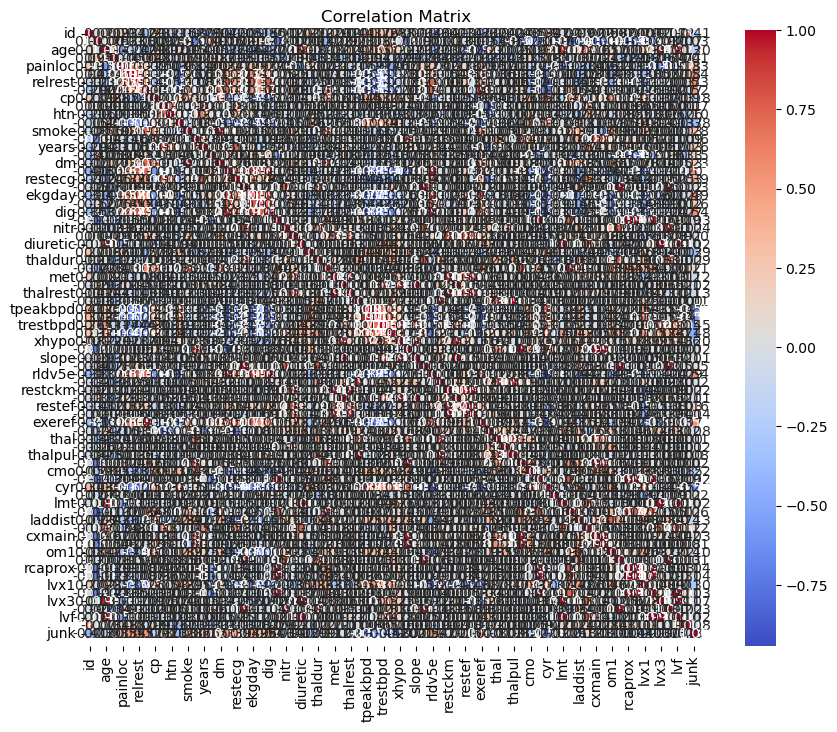

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation
corr = numeric_df.corr()

# Plot as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [44]:
unique_summary = pd.DataFrame({
    'Unique Values': df.nunique(),
    'Missing':       df.isnull().sum(),
    'Missing %':     (df.isnull().sum() / len(df) * 100).round(1),
    'Example Values': [str(df[col].dropna().unique()[:4]) for col in df.columns]
})

print(unique_summary.to_string())

          Unique Values  Missing  Missing %                             Example Values
id                  717        0        0.0                                  [1 2 3 4]
ccf                   8        0        0.0                                  [0 3 2 1]
age                  55        0        0.0                              [63 67 37 41]
sex                   5        0        0.0                              [ 1  0 -9  7]
painloc               7        0        0.0                          [ -9  12   1 -93]
painexer             15        0        0.0                              [-9  6  7 32]
relrest              33        0        0.0                              [-9  2  1  5]
pncaden              11        0        0.0                  [   -9     1    32 26705]
cp                    9        0        0.0                                  [1 4 3 2]
trestbps             64        0        0.0                          [145 160 120 130]
htn                   5        0        0.0